In [14]:
import sys
sys.path.append('../')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from blocking_method.blocking import optimize_support

from time import time

In [15]:
def get_binned_dataset(dname, num_estimators):
    data = pd.read_csv(f"../datasets/{dname}.csv")
    df, _, header, _ = binarize_dataset(data, num_estimators)
    X, y = df.iloc[:, :-1].values, df.iloc[:, -1].values
    X_new, header_new = convert_cumulative_to_binned(X, header)
    header_new = ["intercept"] + header_new
    X_new, y = utils.get_X_y(X_new, y, is_df=False)
    return X_new, y, header_new

for dname, settings in dataset_settings:
    n_estimators = settings["num_estimators"]
    X_new, y, header_new = get_binned_dataset(dname, n_estimators)
    print(X_new.shape, y.shape)

(4521, 25) (4521,)
(6907, 22) (6907,)
(768, 50) (768,)
(4601, 30) (4601,)
(24508, 33) (24508,)


### Comparison

In [16]:
methods = [
    "poisson_ellipsoid_sampling", 
    "uniform_ellipsoid_sampling",
    "blocking", 
    "quadratic_programming", 
    "swapping"
]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

In [17]:
all_datasets_results = {}

for dname in dataset_names:
    all_columns = set()
    method_dfs = {}
    for method in methods:
        with open(f"../analysis/results/methods/{method}.pkl", "rb") as f:
            results = pickle.load(f)
        df = pd.DataFrame(results)
        df = df[df["dataset"] == dname]
        method_dfs[method] = df
        all_columns.update(df.columns)
    all_columns = list(all_columns)

    dfs = []
    for method, df in method_dfs.items():
        df = df.reindex(columns=all_columns)
        df["method"] = method
        dfs.append(df)
    combined_df = pd.concat(dfs, ignore_index=True)
    all_datasets_results[dname] = combined_df

In [22]:
for dname, df in all_datasets_results.items():
    accuracy, logistic, hamming, iou, euclidean, cosine = [], [], [], [], [], []
    for i, row in df.iterrows():
        X, y, header = get_binned_dataset(dname, row["n_estimators"])
        betas = row["betas"]
        beta0 = row["beta0"]
        opt_betas = row["opt_betas"]
        opt_beta0 = row["opt_beta0"]
        predictions = row["predictions"]
        if 'l2' in row:
            l2 = row['l2']

        if betas.shape[0] == 0:
            accuracy.append(0)
            logistic.append(0)
            hamming.append(0)
            iou.append(0)
            euclidean.append(0)
            cosine.append(0)
            continue

        accuracy.append(get_loss(X, y, beta0, betas, loss_type="accuracy"))
        logistic.append(get_loss(X, y, beta0, betas, loss_type="logistic", l2=l2))
        hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=100))

        iou.append(average_pairwise_diversity(betas, inverse_IoU, limit=100))
        euclidean.append(average_pairwise_diversity(betas, euclidean_distance, limit=100))
        cosine.append(average_pairwise_diversity(betas, inverse_cosine_similarity, limit=100))

    df['accuracy'] = accuracy
    df['logistic'] = logistic
    df['hamming'] = hamming
    df['iou'] = iou
    df['euclidean'] = euclidean
    df['cosine'] = cosine

In [24]:
all_datasets_results['compas']

,beta0,l0,m,opt_beta0,n_estimators,dataset,opt_betas,l2,runtime,gap_tolerance,predictions,n_support_set,betas,method,accuracy,logistic,hamming,iou,euclidean,cosine
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.001,1.01,[0.0],50,compas,"[0.7000588106060119, 2.741589757245733, 1.7700...",0.001,16.067128,NaN,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0], [-1.0, ...",15,"[[0.8436358283909191, 2.6030048990059758, 1.58...",poisson_ellipsoid_sampling,0.322209,0.634764,619.133333,0.000000,1.016978,0.013705
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.001,1.01,[0.0],50,compas,"[0.6999906746363074, 2.741775303008865, 1.7724...",0.001,14.479558,NaN,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",15,"[[0.8580985112731045, 2.641664232937785, 1.535...",uniform_ellipsoid_sampling,0.321377,0.637927,635.428571,0.218183,1.770857,0.050789
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.001,1.01,[0.0],50,compas,"[0.700493759197251, 2.74242345903038, 1.772749...",0.001,169.243614,NaN,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",15,"[[0.8033642404582026, 2.581462417961253, 1.707...",blocking,0.319495,0.637733,497.594141,0.000000,0.965727,0.013986
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.001,1.01,[0.0],50,compas,"[0.7004298749101756, 2.742832239175464, 1.7720...",0.001,16.701694,NaN,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",15,"[[0.623425211149098, 2.657899519177268, 1.7642...",quadratic_programming,0.322338,0.638222,254.675354,0.076720,0.739265,0.009194
4,"[0.8707587895601536, 0.8613287799784473, 0.863...",NaN,NaN,0.956773,50,compas,"[0.0, 2.3558714087283326, 1.3999197091192452, ...",NaN,340.830475,0.025,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",15,"[[0.0, 2.172613027034241, 1.1768538665299504, ...",swapping,0.322589,NaN,314.590303,0.279831,1.031576,0.039654


In [37]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        X, y, header = get_binned_dataset(dname, row["n_estimators"])
        betas = row["betas"]
        beta0 = row["beta0"]
        opt_betas = row["opt_betas"]
        opt_beta0 = row["opt_beta0"]
        if 'l2' in row:
            l2 = row['l2']
        print(f"METHOD: {row['method']}")
        get_loss(X, y, beta0, betas, loss_type=loss_type, plot=True, opt_beta0=opt_beta0, opt_betas=opt_betas, l2=l2)

def show_bar_plot(all_datasets_results, dname, metric):
    df = all_datasets_results[dname]
    plot_two_var_bar(df, "method", metric)

METHOD: poisson_ellipsoid_sampling


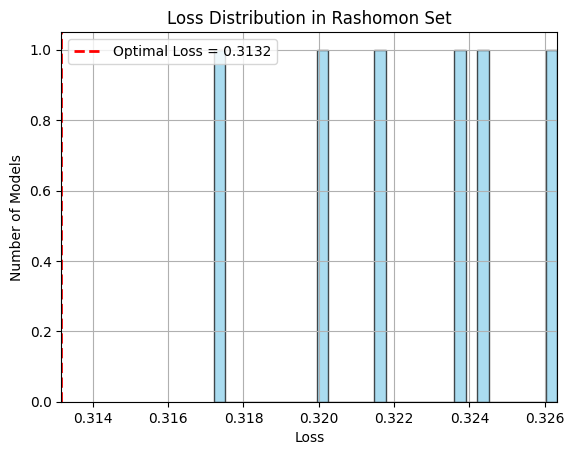

METHOD: uniform_ellipsoid_sampling


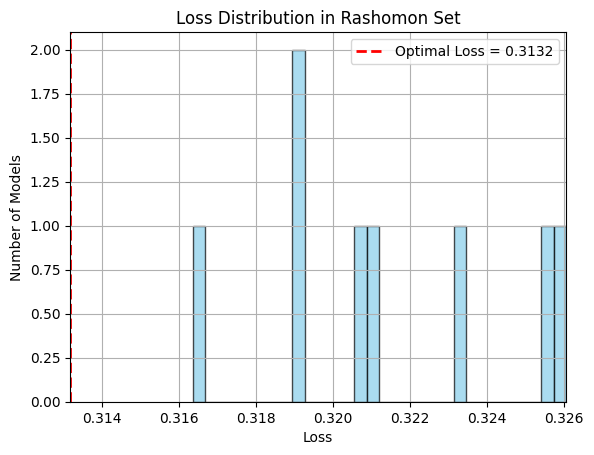

METHOD: blocking


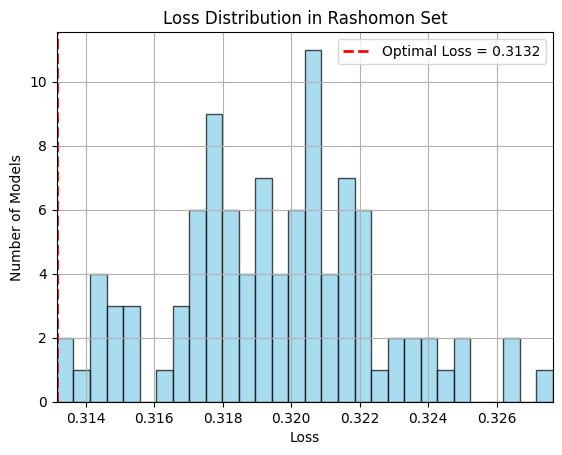

METHOD: quadratic_programming


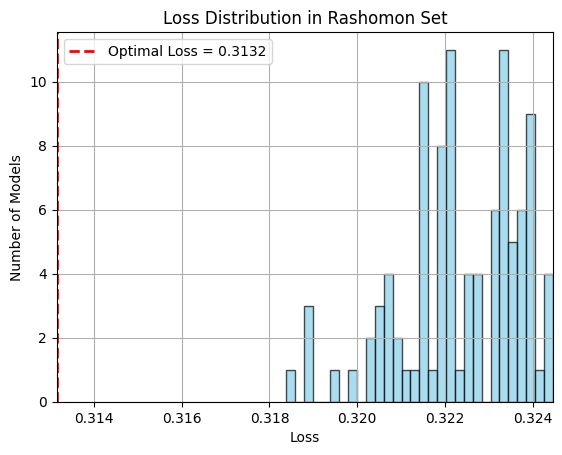

METHOD: swapping


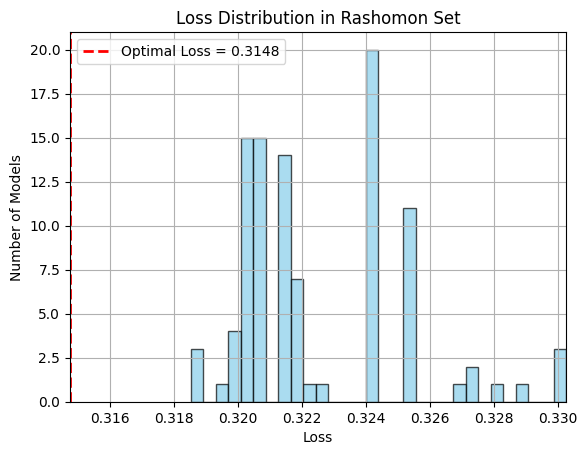

In [ ]:
show_loss_distributions(all_datasets_results, "bank", "accuracy")

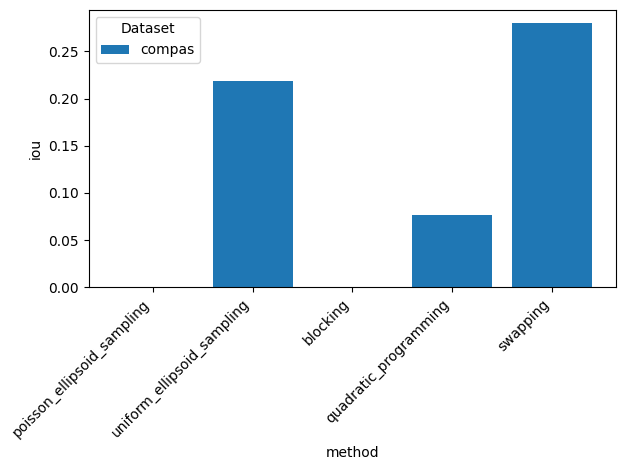

In [ ]:
show_bar_plot(all_datasets_results, "bank", "iou")